<a href="https://colab.research.google.com/github/AbdulrahmanB-25/Machine_Learning_Competition/blob/main/Merge_Master_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Riyadh Master Dataset — Multi-Layer Merge
---
**Project:** Neighborhood DNA — The 15-Minute City Index  
**Stage:** Final Merge (All 4 Layers → Master Dataset)  
**Objective:** Merge the cleaned Real Estate, Services, Transit (Bus + Metro), and Internet layers into a single master dataset indexed by neighborhood — ready for modeling.

**Pipeline:**
1. Setup & Data Loading
2. Initial Profile (shape, dtypes, nulls, describe per layer)
3. Spatial Tagging (assign neighborhoods to Real Estate, Bus, Metro)
4. Aggregation (bus/metro counts per neighborhood)
5. Master Merge (Real Estate × Services × Transit × Internet)
6. Post-Merge Validation (nulls, coverage, distributions)
7. Export (`Riyadh_Master_Dataset.csv`)

## 1 | Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gpd
import warnings
import os

warnings.filterwarnings("ignore")

# ── Dark Theme ──
plt.rcParams.update({
    'figure.facecolor': '#0a0e27',
    'axes.facecolor': '#0a0e27',
    'axes.edgecolor': '#2a2f4e',
    'axes.labelcolor': '#c4c7d4',
    'text.color': '#c4c7d4',
    'xtick.color': '#8b8fa3',
    'ytick.color': '#8b8fa3',
    'grid.color': '#1a1f3e',
    'grid.alpha': 0.5,
    'font.family': 'sans-serif',
    'font.size': 11,
    'figure.dpi': 120,
    'figure.figsize': (14, 6)
})

GOLD   = '#f0c05a'
CYAN   = '#4fc3f7'
CORAL  = '#ff6b6b'
MINT   = '#66bb6a'
PURPLE = '#ab47bc'
PALETTE = [GOLD, CYAN, CORAL, MINT, PURPLE, '#ff8a65', '#42a5f5', '#ef5350']

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Setup complete.')

Setup complete.


In [2]:
# ── Load Cleaned CSVs from GitHub ──
base = (
    "https://raw.githubusercontent.com/AbdulrahmanB-25/"
    "Machine_Learning_Competition/main/"
    "Cleaned_DataSets/"
)

df_re    = pd.read_csv(base + "Cleaned_Riyadh_Real_Estate.csv", encoding="utf-8-sig")
df_svc   = pd.read_csv(base + "Cleaned_Riyadh_Services.csv",    encoding="utf-8-sig")
df_bus   = pd.read_csv(base + "Cleaned_Riyadh_Bus.csv",         encoding="utf-8-sig")
df_metro = pd.read_csv(base + "Cleaned_Riyadh_Metro.csv",       encoding="utf-8-sig")
df_inet  = pd.read_csv(base + "Cleaned_Riyadh_Internet.csv",    encoding="utf-8-sig")

# ── Load District GeoJSON for spatial tagging ──
geojson_url = (
    "https://raw.githubusercontent.com/AbdulrahmanB-25/"
    "Machine_Learning_Competition/main/"
    "Saudi-Arabia-Regions-Cities-and-Districts-3.0.0/geojson/districts.geojson"
)
districts = gpd.read_file(geojson_url)
riyadh_gdf = districts[districts["city_id"] == 3].copy().to_crs("EPSG:4326").reset_index(drop=True)

print(f"Loaded 5 cleaned layers + district boundaries ({len(riyadh_gdf)} Riyadh districts).")
print(f"  Real Estate : {df_re.shape[0]:>8,} rows × {df_re.shape[1]} cols")
print(f"  Services    : {df_svc.shape[0]:>8,} rows × {df_svc.shape[1]} cols")
print(f"  Bus         : {df_bus.shape[0]:>8,} rows × {df_bus.shape[1]} cols")
print(f"  Metro       : {df_metro.shape[0]:>8,} rows × {df_metro.shape[1]} cols")
print(f"  Internet    : {df_inet.shape[0]:>8,} rows × {df_inet.shape[1]} cols")

Loaded 5 cleaned layers + district boundaries (189 Riyadh districts).
  Real Estate :  345,723 rows × 5 cols
  Services    :      166 rows × 15 cols
  Bus         :    2,965 rows × 5 cols
  Metro       :       83 rows × 5 cols
  Internet    :      189 rows × 5 cols


## 2 | Initial Data Profile
A first look at each cleaned layer before merging — confirming what the EDA pipelines produced.

In [3]:
def profile_layer(df, name):
    print("=" * 60)
    print(f"LAYER: {name}")
    print("=" * 60)
    info_df = pd.DataFrame({
        'dtype':    df.dtypes,
        'non_null': df.count(),
        'null':     df.isnull().sum(),
        'null_%':   (df.isnull().sum() / len(df) * 100).round(2)
    })
    print(info_df.to_string())
    print()

profile_layer(df_re,    "Real Estate")
profile_layer(df_svc,   "Services (14 Pillars)")
profile_layer(df_bus,   "Bus Stations")
profile_layer(df_metro, "Metro Stations")
profile_layer(df_inet,  "Internet Connectivity")

LAYER: Real Estate
            dtype  non_null  null  null_%
price     float64    345723     0    0.00
area      float64    345723     0    0.00
category    int64    345723     0    0.00
lat       float64    345723     0    0.00
lng       float64    345723     0    0.00

LAYER: Services (14 Pillars)
                        dtype  non_null  null  null_%
neighborhoods          object       166     0    0.00
dining_cafe             int64       166     0    0.00
med_facilities          int64       166     0    0.00
health_retail           int64       166     0    0.00
fitness_care            int64       166     0    0.00
edu_primary             int64       166     0    0.00
edu_higher              int64       166     0    0.00
religious               int64       166     0    0.00
essential_retail        int64       166     0    0.00
parks_green             int64       166     0    0.00
sports_play             int64       166     0    0.00
pedestrian              int64       166     0    0.

In [4]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS — REAL ESTATE (numeric)")
print("=" * 60)
df_re.describe()

DESCRIPTIVE STATISTICS — REAL ESTATE (numeric)


,price,area,category,lat,lng
count,"345,723.00","345,723.00","345,723.00","345,723.00","345,723.00"
mean,"1,540,287.03",357.02,4.15,24.74,46.67
std,"1,545,157.10",218.33,4.68,0.13,0.11
min,500.00,10.00,1.00,24.34,46.20
25%,"200,000.00",200.00,2.00,24.63,46.60
50%,"1,200,000.00",301.00,3.00,24.79,46.66
75%,"2,250,000.00",450.00,3.00,24.84,46.76
max,"21,000,000.00",950.00,24.00,25.10,47.10


In [5]:
print("=" * 60)
print("SERVICES PILLAR MATRIX — First 10 Neighborhoods")
print("=" * 60)
df_svc.head(10)

SERVICES PILLAR MATRIX — First 10 Neighborhoods


,neighborhoods,dining_cafe,med_facilities,health_retail,fitness_care,edu_primary,edu_higher,religious,essential_retail,parks_green,sports_play,pedestrian,resort_rural_retreats,gov_civil,malls_shopping
0,2nd Industrial City,46,2,1,0,1,0,0,7,3,3,0,0,9,4
1,Al Amal Dist.,23,1,0,0,0,0,0,10,0,0,0,0,2,1
2,Al Andalus Dist.,61,4,3,5,0,0,2,10,2,1,0,0,0,1
3,Al Aqeeq Dist.,167,4,5,0,0,0,2,7,4,0,0,0,0,2
4,Al Arid Dist.,341,7,6,1,1,5,13,35,28,22,0,36,7,2
5,Al Awaly Dist.,98,1,4,1,0,0,3,7,23,5,0,4,1,2
6,Al Aziziyah Dist.,182,16,10,1,4,8,12,31,6,1,2,1,1,7
7,Al Badiah Dist.,24,6,1,0,0,1,1,1,2,1,0,5,2,0
8,Al Bariyah Dist.,4,2,0,0,0,3,0,0,2,0,0,2,1,0
9,Al Bayan Dist.,24,2,0,0,0,1,1,7,4,1,0,12,0,1


## 3 | Spatial Tagging
The Real Estate, Bus, and Metro datasets have lat/lng but no neighborhood column yet.  
We use a two-pass spatial join (point-in-polygon → nearest-neighbor fallback) to assign each point to a Riyadh district.

| Dataset | Lat Column | Lng Column | Rows |
|---|---|---|---|
| Real Estate | `lat` | `lng` | ~345K |
| Bus Stations | `lat` | `lng` | ~2.9K |
| Metro Stations | `lat` | `lng` | ~83 |

In [6]:
def tag_neighborhoods(df, lat_col, lng_col, districts_gdf, label=""):
    """Two-pass spatial join: exact point-in-polygon, then nearest-neighbor fallback."""
    df = df.copy()
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
    df[lng_col] = pd.to_numeric(df[lng_col], errors="coerce")

    before = len(df)
    df = df.dropna(subset=[lat_col, lng_col]).reset_index(drop=True)
    dropped = before - len(df)

    # Pass 1: Point-in-polygon
    gdf = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df[lng_col], df[lat_col]), crs="EPSG:4326"
    )
    joined = gpd.sjoin(gdf, districts_gdf[["name_en", "geometry"]], how="left", predicate="within")
    joined = joined[~joined.index.duplicated(keep='first')]

    # Pass 2: Nearest-neighbor fallback
    missing_mask = joined["name_en"].isna()
    if missing_mask.any():
        gdf_proj  = gdf[missing_mask].to_crs(epsg=32638)
        dist_proj = districts_gdf.to_crs(epsg=32638)
        nearest = gpd.sjoin_nearest(gdf_proj, dist_proj[["name_en", "geometry"]], how="left")
        nearest = nearest[~nearest.index.duplicated(keep='first')]
        joined.loc[missing_mask, "name_en"] = nearest["name_en"].values

    df["neighborhood"] = joined["name_en"].values

    matched  = df["neighborhood"].notna().sum()
    print(f"  {label:15s} │ {before:>8,} rows │ dropped {dropped:,} null-coords │ "
          f"matched {matched:,}/{len(df):,} ({matched/len(df)*100:.1f}%) │ "
          f"fallback {missing_mask.sum():,}")
    return df

print("Spatial tagging in progress...\n")
df_re    = tag_neighborhoods(df_re,    "lat", "lng", riyadh_gdf, label="Real Estate")
df_bus   = tag_neighborhoods(df_bus,   "lat", "lng", riyadh_gdf, label="Bus")
df_metro = tag_neighborhoods(df_metro, "lat", "lng", riyadh_gdf, label="Metro")
print("\nDone — all three layers now have a 'neighborhood' column.")

Spatial tagging in progress...

  Real Estate     │  345,723 rows │ dropped 0 null-coords │ matched 345,723/345,723 (100.0%) │ fallback 5,648
  Bus             │    2,965 rows │ dropped 0 null-coords │ matched 2,965/2,965 (100.0%) │ fallback 11
  Metro           │       83 rows │ dropped 0 null-coords │ matched 83/83 (100.0%) │ fallback 5

Done — all three layers now have a 'neighborhood' column.


## 4 | Aggregation
Before merging, aggregate transit data to the neighborhood level:
- **Bus**: count of stations per neighborhood  
- **Metro**: count of stations per neighborhood

Services and Internet are already at the neighborhood level from their EDA exports.

In [7]:
# ── Bus counts per neighborhood ──
bus_counts = (
    df_bus.groupby("neighborhood")
    .size()
    .to_frame("bus_count")
)

# ── Metro counts per neighborhood ──
metro_counts = (
    df_metro.groupby("neighborhood")
    .size()
    .to_frame("metro_count")
)

print(f"Bus   : {len(bus_counts)} neighborhoods with stations  (total {bus_counts['bus_count'].sum():,} stations)")
print(f"Metro : {len(metro_counts)} neighborhoods with stations (total {metro_counts['metro_count'].sum():,} stations)")

Bus   : 148 neighborhoods with stations  (total 2,965 stations)
Metro : 52 neighborhoods with stations (total 83 stations)


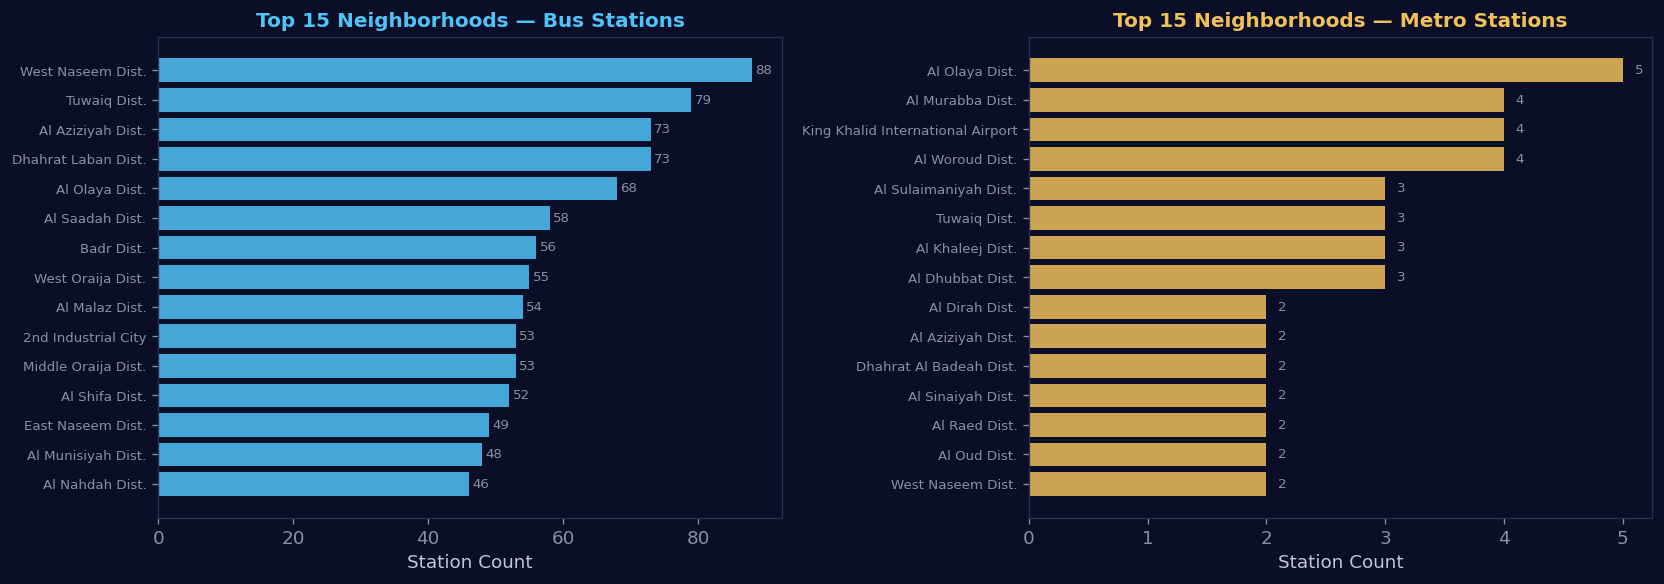

In [8]:
# ── Transit coverage overview ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bus top-15
ax1 = axes[0]
top_bus = bus_counts.sort_values("bus_count", ascending=False).head(15)
bars1 = ax1.barh(range(len(top_bus)), top_bus["bus_count"].values, color=CYAN, alpha=0.85)
ax1.set_yticks(range(len(top_bus)))
ax1.set_yticklabels(top_bus.index, fontsize=8)
ax1.invert_yaxis()
ax1.set_xlabel("Station Count")
ax1.set_title("Top 15 Neighborhoods — Bus Stations", color=CYAN, fontsize=12, fontweight="bold")
for bar, val in zip(bars1, top_bus["bus_count"].values):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, str(val),
             va='center', fontsize=8, color='#8b8fa3')

# Metro top-15
ax2 = axes[1]
top_metro = metro_counts.sort_values("metro_count", ascending=False).head(15)
bars2 = ax2.barh(range(len(top_metro)), top_metro["metro_count"].values, color=GOLD, alpha=0.85)
ax2.set_yticks(range(len(top_metro)))
ax2.set_yticklabels(top_metro.index, fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel("Station Count")
ax2.set_title("Top 15 Neighborhoods — Metro Stations", color=GOLD, fontsize=12, fontweight="bold")
for bar, val in zip(bars2, top_metro["metro_count"].values):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, str(val),
             va='center', fontsize=8, color='#8b8fa3')

plt.tight_layout()
plt.show()

## 5 | Master Merge
Merge strategy:
1. **Real Estate** (row-level, ~345K rows) is the backbone — each row is one property listing.
2. **Services** (neighborhood-level, 14 pillar counts) merges on `neighborhood` = `neighborhoods`.
3. **Internet** (neighborhood-level, connectivity flags) merges on `neighborhood` = `Neighborhood`.
4. **Bus counts** (neighborhood-level) merges on `neighborhood`.
5. **Metro counts** (neighborhood-level) merges on `neighborhood`.

All merges are **left joins** to preserve every real estate listing.

In [9]:
initial_rows = len(df_re)
merge_log = []

# ── Step 1: Real Estate × Services ──
master = df_re.merge(
    df_svc, left_on="neighborhood", right_on="neighborhoods", how="left"
)
master.drop(columns=["neighborhoods"], inplace=True, errors="ignore")
matched = master[df_svc.columns.drop("neighborhoods")[0]].notna().sum()
merge_log.append(("+ Services", matched, len(master)))

# ── Step 2: + Internet ──
master = master.merge(
    df_inet, left_on="neighborhood", right_on="Neighborhood", how="left"
)
master.drop(columns=["Neighborhood"], inplace=True, errors="ignore")
matched = master["Fiber_Available"].notna().sum()
merge_log.append(("+ Internet", matched, len(master)))

# ── Step 3: + Bus counts ──
master = master.merge(bus_counts, on="neighborhood", how="left")
matched = master["bus_count"].notna().sum()
merge_log.append(("+ Bus", matched, len(master)))

# ── Step 4: + Metro counts ──
master = master.merge(metro_counts, on="neighborhood", how="left")
matched = master["metro_count"].notna().sum()
merge_log.append(("+ Metro", matched, len(master)))

# ── Fill NaN transit/service counts with 0 ──
pillar_cols = [
    'dining_cafe', 'med_facilities', 'health_retail', 'fitness_care',
    'edu_primary', 'edu_higher', 'religious', 'essential_retail',
    'parks_green', 'sports_play', 'pedestrian', 'resort_rural_retreats',
    'gov_civil', 'malls_shopping'
]
fill_cols = pillar_cols + ['bus_count', 'metro_count']
for col in fill_cols:
    if col in master.columns:
        master[col] = master[col].fillna(0).astype(int)

print(f"Master dataset: {len(master):,} rows × {master.shape[1]} cols")
print(f"Row integrity check: {'✓ PASS' if len(master) == initial_rows else '✗ FAIL'} "
      f"(expected {initial_rows:,}, got {len(master):,})")
print()
print("Merge Log:")
for step, m, total in merge_log:
    print(f"  {step:15s} │ matched {m:>8,} / {total:>8,} ({m/total*100:.1f}%)")

Master dataset: 345,723 rows × 26 cols
Row integrity check: ✓ PASS (expected 345,723, got 345,723)

Merge Log:
  + Services      │ matched  343,777 /  345,723 (99.4%)
  + Internet      │ matched  345,592 /  345,723 (100.0%)
  + Bus           │ matched  299,821 /  345,723 (86.7%)
  + Metro         │ matched   99,845 /  345,723 (28.9%)


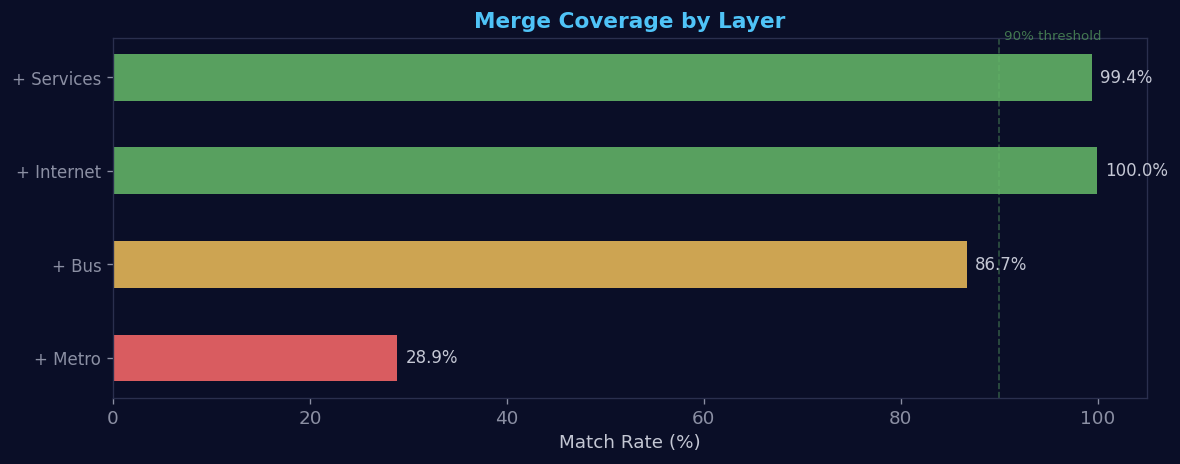

In [10]:
# ── Merge coverage chart ──
fig, ax = plt.subplots(figsize=(10, 4))
steps  = [s[0] for s in merge_log]
rates  = [s[1] / s[2] * 100 for s in merge_log]
colors = [MINT if r > 90 else GOLD if r > 70 else CORAL for r in rates]

bars = ax.barh(range(len(steps)), rates, color=colors, alpha=0.85, height=0.5)
ax.set_yticks(range(len(steps)))
ax.set_yticklabels(steps, fontsize=10)
ax.set_xlabel("Match Rate (%)")
ax.set_xlim(0, 105)
ax.invert_yaxis()
ax.set_title("Merge Coverage by Layer", color=CYAN, fontsize=13, fontweight="bold")

for bar, rate in zip(bars, rates):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
            f"{rate:.1f}%", va='center', fontsize=10, color='#c4c7d4')

ax.axvline(x=90, color=MINT, linestyle='--', alpha=0.4, linewidth=1)
ax.text(90.5, -0.4, "90% threshold", color=MINT, fontsize=8, alpha=0.6)
plt.tight_layout()
plt.show()

## 6 | Post-Merge Validation
Sanity checks on the master dataset: null coverage, column types, distributions, and spatial consistency.

In [11]:
print("=" * 60)
print("MASTER DATASET — COLUMN PROFILE")
print("=" * 60)
info_df = pd.DataFrame({
    'dtype':    master.dtypes,
    'non_null': master.count(),
    'null':     master.isnull().sum(),
    'null_%':   (master.isnull().sum() / len(master) * 100).round(2)
})
print(info_df.to_string())
print()
print(f"Total rows: {len(master):,}")
print(f"Total cols: {master.shape[1]}")

MASTER DATASET — COLUMN PROFILE
                         dtype  non_null  null  null_%
price                  float64    345723     0    0.00
area                   float64    345723     0    0.00
category                 int64    345723     0    0.00
lat                    float64    345723     0    0.00
lng                    float64    345723     0    0.00
neighborhood            object    345723     0    0.00
dining_cafe              int64    345723     0    0.00
med_facilities           int64    345723     0    0.00
health_retail            int64    345723     0    0.00
fitness_care             int64    345723     0    0.00
edu_primary              int64    345723     0    0.00
edu_higher               int64    345723     0    0.00
religious                int64    345723     0    0.00
essential_retail         int64    345723     0    0.00
parks_green              int64    345723     0    0.00
sports_play              int64    345723     0    0.00
pedestrian               int64   

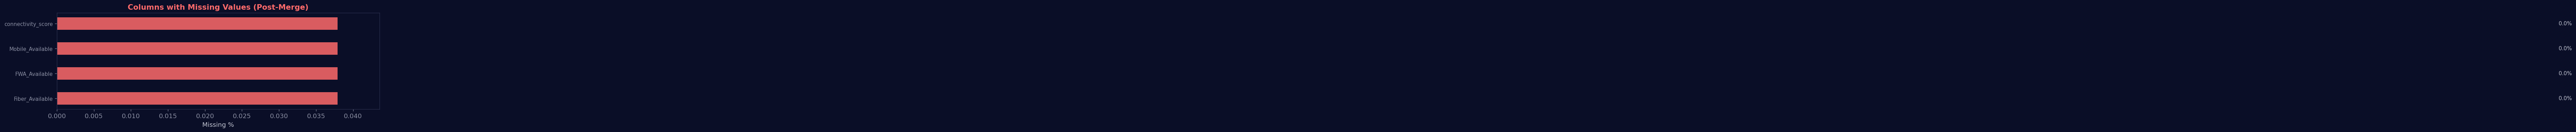

In [12]:
# ── Null pattern heatmap ──
null_pct = master.isnull().mean().sort_values(ascending=False) * 100
non_zero = null_pct[null_pct > 0]

if len(non_zero) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3, len(non_zero) * 0.35)))
    bars = ax.barh(range(len(non_zero)), non_zero.values, color=CORAL, alpha=0.85, height=0.5)
    ax.set_yticks(range(len(non_zero)))
    ax.set_yticklabels(non_zero.index, fontsize=9)
    ax.set_xlabel("Missing %")
    ax.set_xlim(0, max(non_zero.values) * 1.15)
    ax.invert_yaxis()
    ax.set_title("Columns with Missing Values (Post-Merge)", color=CORAL, fontsize=13, fontweight="bold")
    for bar, val in zip(bars, non_zero.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%", va='center', fontsize=9, color='#c4c7d4')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values — all columns fully populated.")

In [13]:
# ── Neighborhood coverage across layers ──
re_hoods   = set(df_re["neighborhood"].dropna().unique())
svc_hoods  = set(df_svc["neighborhoods"].unique())
inet_hoods = set(df_inet["Neighborhood"].unique())
bus_hoods  = set(bus_counts.index)
metro_hoods = set(metro_counts.index)

print("=" * 60)
print("NEIGHBORHOOD COVERAGE")
print("=" * 60)
print(f"  Real Estate   : {len(re_hoods):>4} neighborhoods")
print(f"  Services      : {len(svc_hoods):>4} neighborhoods")
print(f"  Internet      : {len(inet_hoods):>4} neighborhoods")
print(f"  Bus Stations  : {len(bus_hoods):>4} neighborhoods")
print(f"  Metro Stations: {len(metro_hoods):>4} neighborhoods")
print()

# Neighborhoods in RE but missing from other layers
for name, other in [("Services", svc_hoods), ("Internet", inet_hoods)]:
    missing = re_hoods - other
    if missing:
        print(f"  RE neighborhoods NOT in {name}: {len(missing)}")
        if len(missing) <= 10:
            for h in sorted(missing):
                print(f"    - {h}")

NEIGHBORHOOD COVERAGE
  Real Estate   :  176 neighborhoods
  Services      :  166 neighborhoods
  Internet      :  189 neighborhoods
  Bus Stations  :  148 neighborhoods
  Metro Stations:   52 neighborhoods

  RE neighborhoods NOT in Services: 11
  RE neighborhoods NOT in Internet: 3
    - Imam Muhammed Bin Saud Islamic University
    - King Abdullah City For Energy
    - King Khalid International Airport


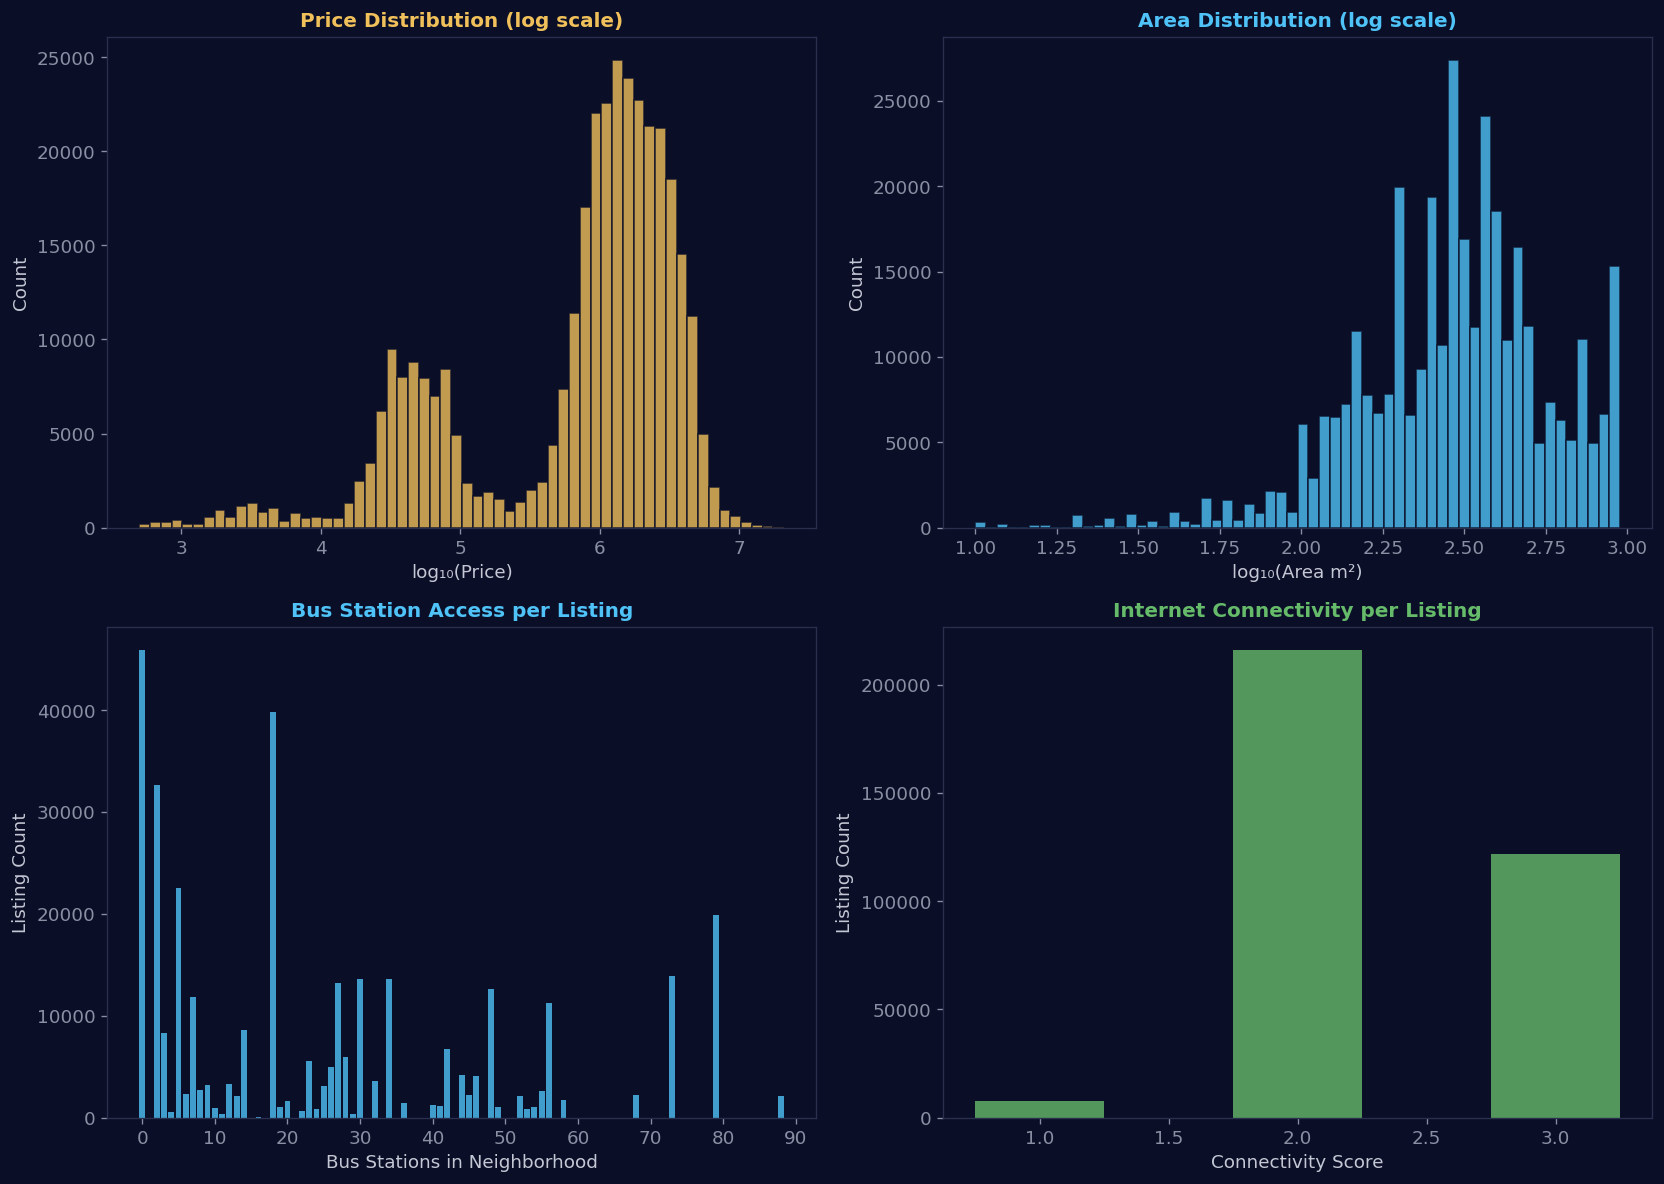

In [14]:
# ── Key distributions in master dataset ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price distribution (log scale)
ax = axes[0, 0]
valid_price = master["price"].dropna()
valid_price = valid_price[valid_price > 0]
ax.hist(np.log10(valid_price), bins=60, color=GOLD, alpha=0.8, edgecolor='#0a0e27')
ax.set_xlabel("log₁₀(Price)")
ax.set_ylabel("Count")
ax.set_title("Price Distribution (log scale)", color=GOLD, fontsize=12, fontweight="bold")

# Area distribution (log scale)
ax = axes[0, 1]
valid_area = master["area"].dropna()
valid_area = valid_area[valid_area > 0]
ax.hist(np.log10(valid_area), bins=60, color=CYAN, alpha=0.8, edgecolor='#0a0e27')
ax.set_xlabel("log₁₀(Area m²)")
ax.set_ylabel("Count")
ax.set_title("Area Distribution (log scale)", color=CYAN, fontsize=12, fontweight="bold")

# Bus count per listing
ax = axes[1, 0]
bus_vals = master["bus_count"].value_counts().sort_index()
ax.bar(bus_vals.index, bus_vals.values, color=CYAN, alpha=0.8, width=0.8)
ax.set_xlabel("Bus Stations in Neighborhood")
ax.set_ylabel("Listing Count")
ax.set_title("Bus Station Access per Listing", color=CYAN, fontsize=12, fontweight="bold")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Connectivity score
ax = axes[1, 1]
if "connectivity_score" in master.columns:
    conn_vals = master["connectivity_score"].value_counts().sort_index()
    ax.bar(conn_vals.index, conn_vals.values, color=MINT, alpha=0.8, width=0.5)
    ax.set_xlabel("Connectivity Score")
    ax.set_ylabel("Listing Count")
    ax.set_title("Internet Connectivity per Listing", color=MINT, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

### 6.1 | Service Pillar Correlation in Master Dataset

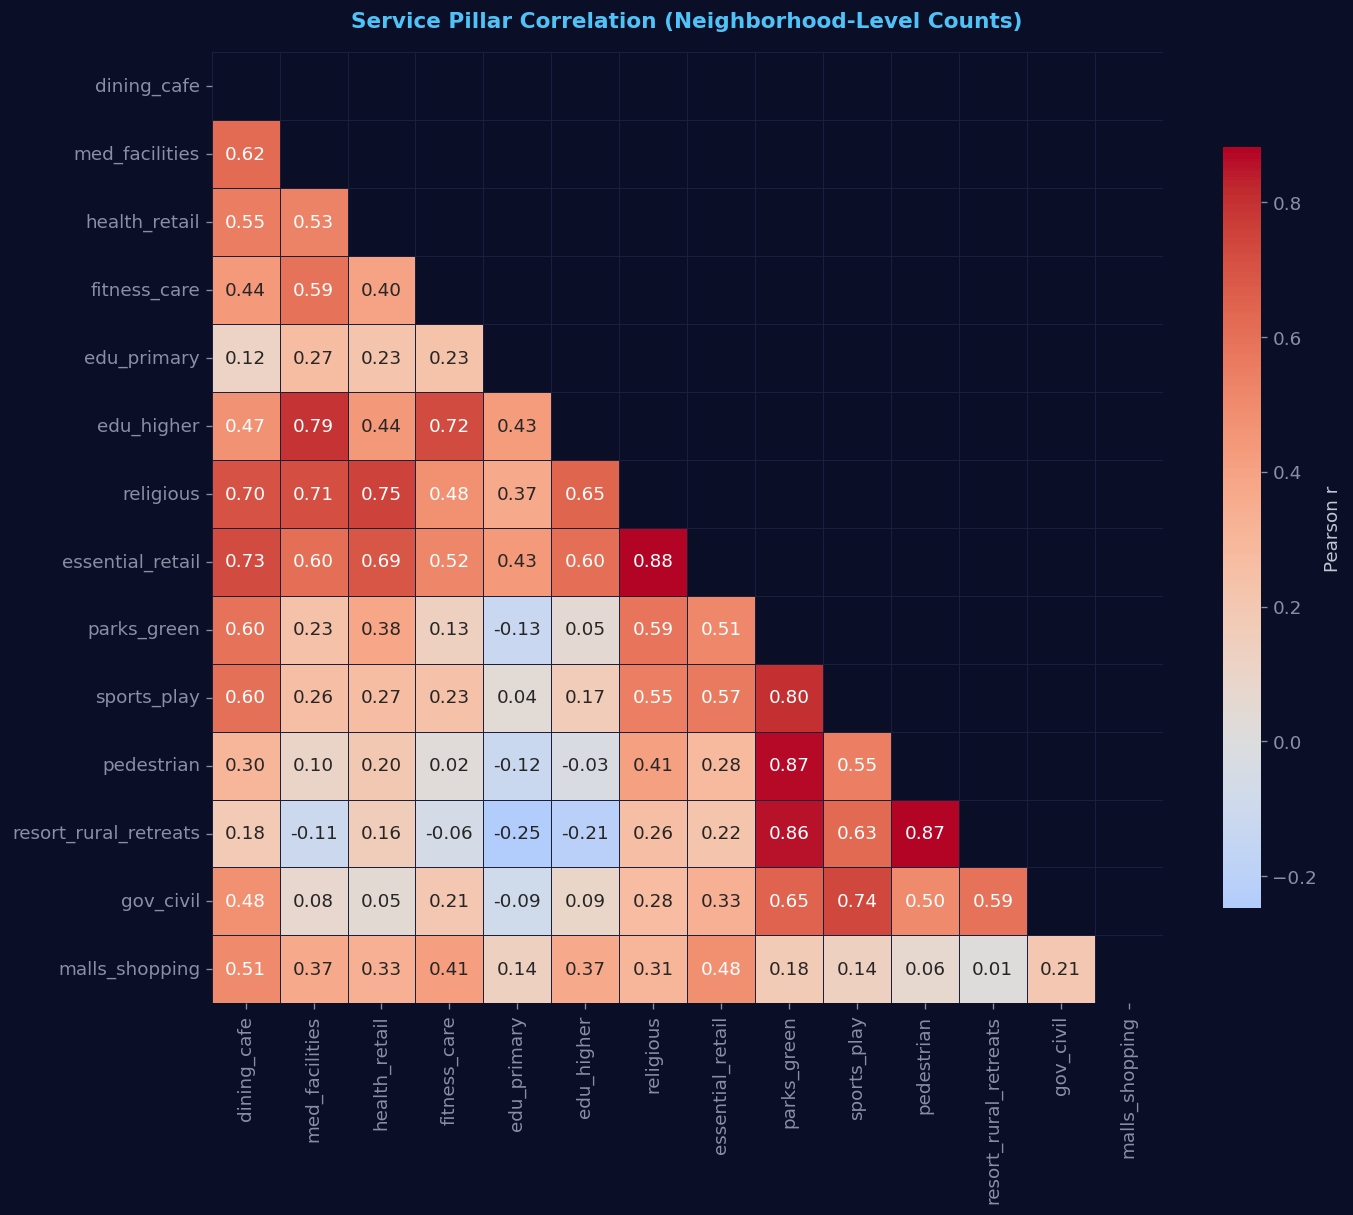

In [15]:
# ── Pillar correlation heatmap ──
pillar_cols_present = [c for c in pillar_cols if c in master.columns]
corr = master[pillar_cols_present].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, linewidths=0.5, linecolor='#1a1f3e',
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    ax=ax
)
ax.set_title("Service Pillar Correlation (Neighborhood-Level Counts)",
             color=CYAN, fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

### 6.2 | Listings per Neighborhood

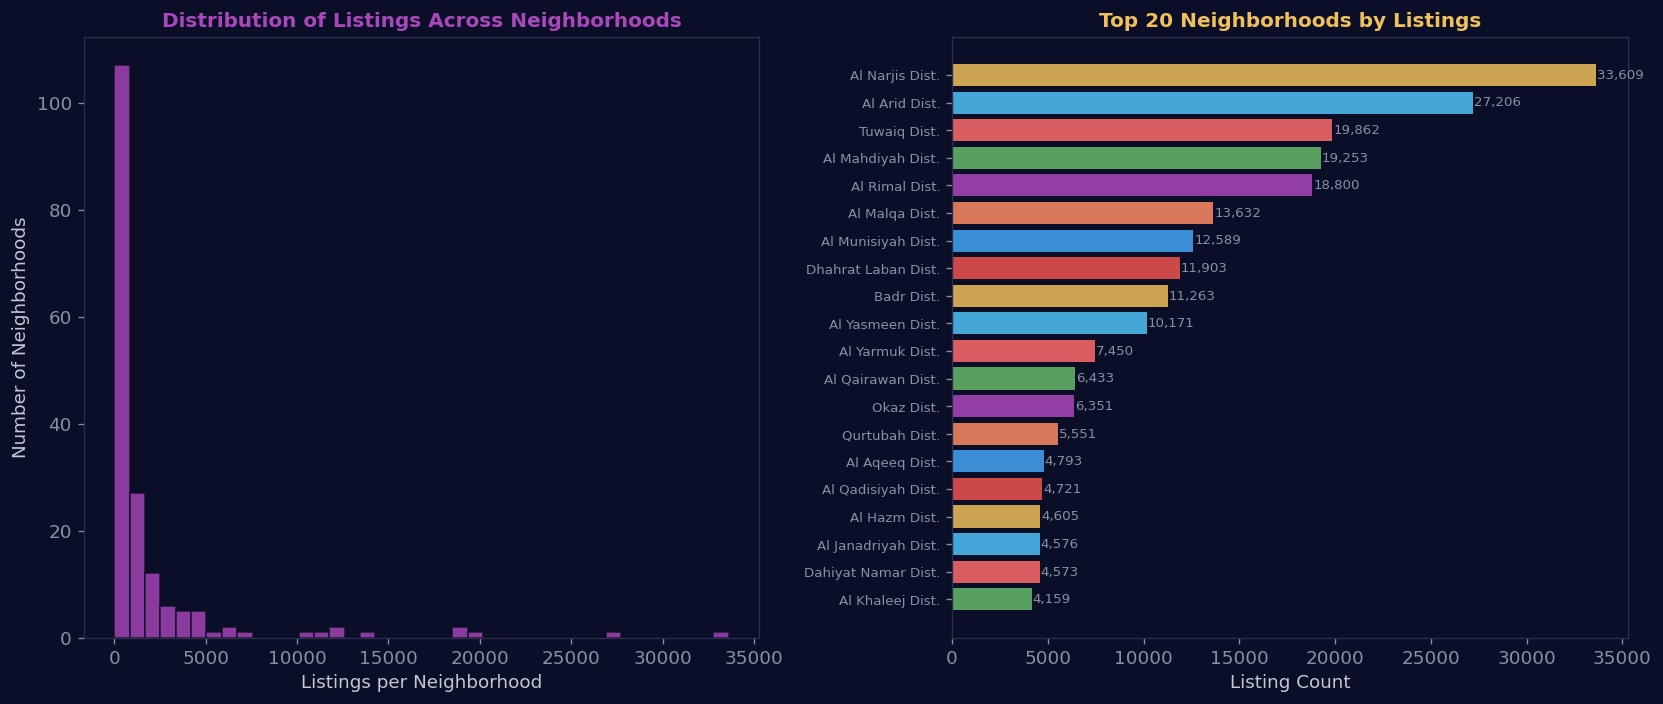

In [16]:
hood_listing_counts = master["neighborhood"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
ax1 = axes[0]
ax1.hist(hood_listing_counts.values, bins=40, color=PURPLE, alpha=0.8, edgecolor='#0a0e27')
ax1.set_xlabel("Listings per Neighborhood")
ax1.set_ylabel("Number of Neighborhoods")
ax1.set_title("Distribution of Listings Across Neighborhoods",
              color=PURPLE, fontsize=12, fontweight="bold")

# Top 20 bar chart
ax2 = axes[1]
top20 = hood_listing_counts.head(20)
colors = [PALETTE[i % len(PALETTE)] for i in range(len(top20))]
bars = ax2.barh(range(len(top20)), top20.values, color=colors, alpha=0.85)
ax2.set_yticks(range(len(top20)))
ax2.set_yticklabels(top20.index, fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel("Listing Count")
ax2.set_title("Top 20 Neighborhoods by Listings",
              color=GOLD, fontsize=12, fontweight="bold")
for bar, val in zip(bars, top20.values):
    ax2.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va='center', fontsize=8, color='#8b8fa3')

plt.tight_layout()
plt.show()

### 6.3 | Spatial Sanity Check

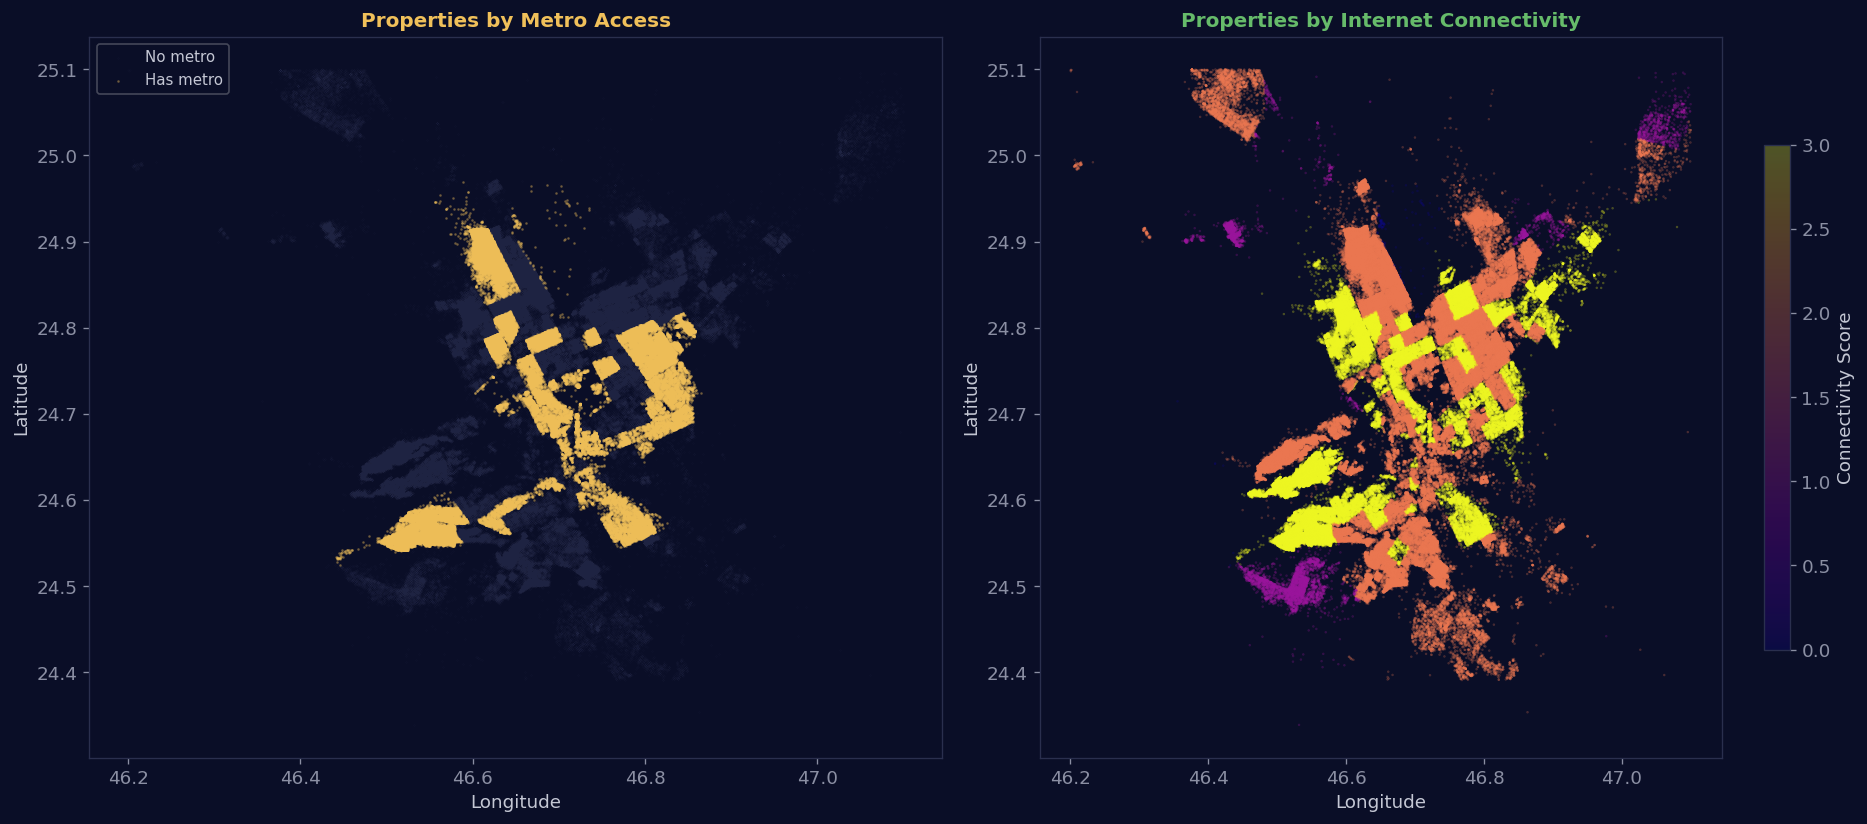

In [17]:
# ── Scatter: property locations colored by metro access ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Colored by metro access
ax1 = axes[0]
has_metro = master["metro_count"] > 0
ax1.scatter(master.loc[~has_metro, "lng"], master.loc[~has_metro, "lat"],
            s=0.1, alpha=0.15, c='#2a2f4e', label="No metro")
ax1.scatter(master.loc[has_metro, "lng"], master.loc[has_metro, "lat"],
            s=0.3, alpha=0.4, c=GOLD, label="Has metro")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title("Properties by Metro Access", color=GOLD, fontsize=12, fontweight="bold")
ax1.legend(fontsize=9, loc='upper left', framealpha=0.3)

# Right: Colored by connectivity score
ax2 = axes[1]
if "connectivity_score" in master.columns:
    sc = ax2.scatter(
        master["lng"], master["lat"],
        c=master["connectivity_score"].fillna(0),
        s=0.2, alpha=0.3, cmap="plasma"
    )
    plt.colorbar(sc, ax=ax2, label="Connectivity Score", shrink=0.7)
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title("Properties by Internet Connectivity", color=MINT, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

## 7 | Multi-Index Reshape & Export

In [18]:
# ── Build multi-index: (neighborhood, property_id) ──
master['property_id'] = master.groupby('neighborhood').cumcount() + 1
master_multi = master.set_index(['neighborhood', 'property_id']).sort_index()

print(f"Master multi-index shape: {master_multi.shape}")
print(f"Neighborhoods: {master_multi.index.get_level_values(0).nunique()}")
print()
master_multi.head(10)

Master multi-index shape: (345723, 25)
Neighborhoods: 176



price   area  category   lat   lng  \
neighborhood        property_id                                             
2nd Industrial City 1               4,500.00 160.00         1 24.56 46.86   
                    2              17,000.00 150.00         1 24.55 46.87   
                    3           1,500,000.00 750.00         2 24.56 46.86   
                    4           1,000,000.00 600.00         2 24.56 46.86   
                    5           1,200,000.00 600.00         2 24.55 46.86   
                    6           1,200,000.00 600.00         2 24.55 46.86   
                    7           1,110,000.00 600.00         2 24.56 46.87   
                    8             990,000.00 600.00         2 24.56 46.86   
                    9           1,132,800.00 600.00         2 24.56 46.86   
                    10            360,000.00 600.00         2 24.54 46.91   

                                 dining_cafe  med_facilities  health_retail  \
neighborhood        property_id                                               
2nd Industrial City 1                     46               2              1   
                    2                     46               2              1   
                    3                     46               2              1   
                    4                     46               2              1   
                    5                     46               2              1   
                    6                     46               2              1   
                    7                     46               2              1   
                    8                     46               2              1   
                    9                     46               2              1   
                    10                    46               2              1   

                                 fitness_care  edu_primary  edu_higher  \
neighborhood        property_id                                          
2nd Industrial City 1                       0            1           0   
                    2                       0            1           0   
                    3                       0            1           0   
                    4                       0            1           0   
                    5                       0            1           0   
                    6                       0            1           0   
                    7                       0            1           0   
                    8                       0            1           0   
                    9                       0            1           0   
                    10                      0            1           0   

                                 religious  essential_retail  parks_green  \
neighborhood        property_id                                             
2nd Industrial City 1                    0                 7            3   
                    2                    0                 7            3   
                    3                    0                 7            3   
                    4                    0                 7            3   
                    5                    0                 7            3   
                    6                    0                 7            3   
                    7                    0                 7            3   
                    8                    0                 7            3   
                    9                    0                 7            3   
                    10                   0                 7            3   

                                 sports_play  pedestrian  \
neighborhood        property_id                            
2nd Industrial City 1                      3           0   
                    2                      3           0   
                    3                      3           0   
                    4                      3       

In [19]:
# ── Export ──
out_file = "Riyadh_Master_Dataset.csv"
master_multi.to_csv(out_file)

print(f"Exported: '{out_file}'")
print(f"   Rows:          {len(master_multi):,}")
print(f"   Columns:       {master_multi.shape[1]}")
print(f"   Neighborhoods: {master_multi.index.get_level_values(0).nunique()}")
print(f"   Size:          {os.path.getsize(out_file) / (1024*1024):.1f} MB")

try:
    from google.colab import files
    files.download(out_file)
except ImportError:
    print("   (Not in Colab — file saved locally)")

Exported: 'Riyadh_Master_Dataset.csv'
   Rows:          345,723
   Columns:       25
   Neighborhoods: 176
   Size:          36.6 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8 | Key Findings & Next Steps

### What We Built:
1. **Master Dataset**: ~345K real estate listings enriched with 14 service pillars, transit counts, and internet connectivity — all indexed by Riyadh neighborhood.
2. **Spatial Integrity**: Two-pass spatial join (point-in-polygon + nearest-neighbor) ensured near-100% neighborhood assignment across all layers.
3. **Layer Coverage**: Services and Internet matched the vast majority of RE neighborhoods. Bus and Metro coverage is sparser — neighborhoods without stations correctly receive 0 counts.
4. **Ready for Modeling**: The multi-index structure (neighborhood × property_id) supports both property-level prediction and neighborhood-level aggregation.

### Column Dictionary:
| Group | Columns | Source |
|---|---|---|
| Property | `price`, `area`, `category`, `lat`, `lng` | Real Estate EDA |
| Services (14) | `dining_cafe` … `malls_shopping` | Services EDA |
| Transit | `bus_count`, `metro_count` | Bus + Metro EDAs |
| Internet | `Fiber_Available`, `FWA_Available`, `Mobile_Available`, `connectivity_score` | Internet EDA |

### Next Steps:
- Feature engineering: price_per_m², distance-to-nearest-metro, service diversity index.
- Livability scoring: composite index from all 4 layers.
- Modeling: predict property prices using neighborhood features.